# Lab Segmentation 1

In [3]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter,binary_opening, binary_closing
#import cv2
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


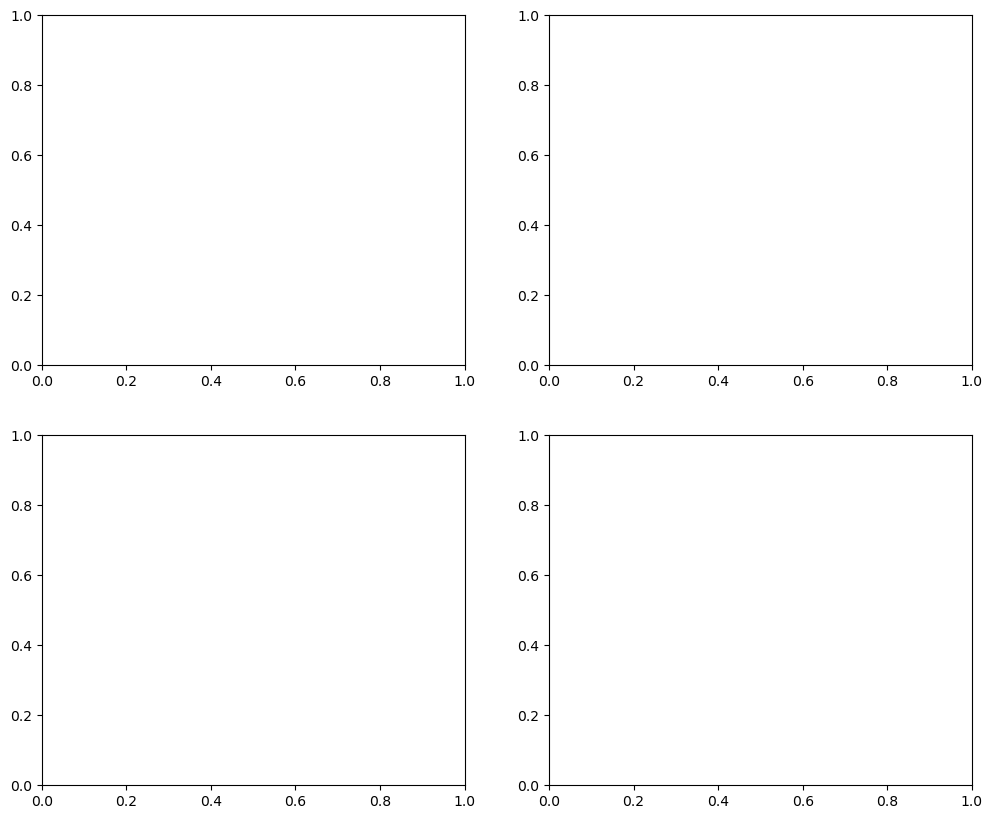

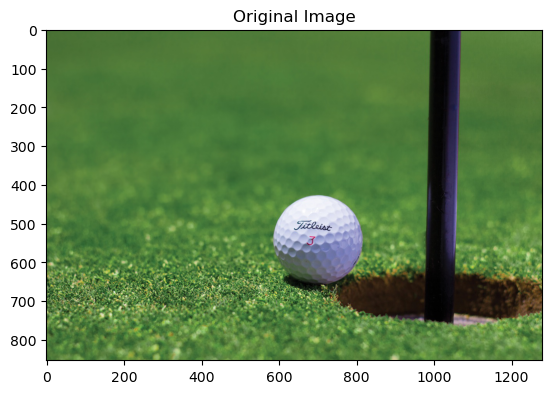

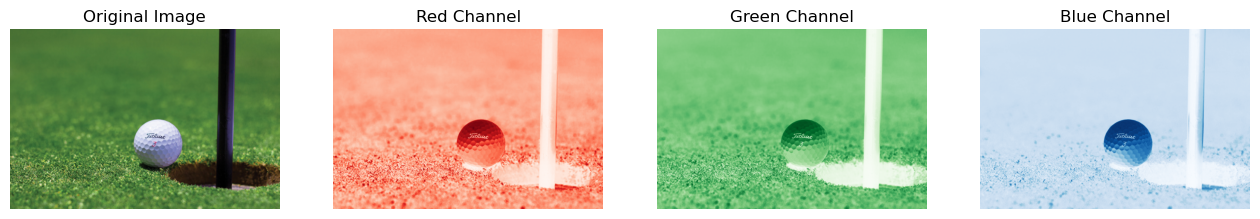

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


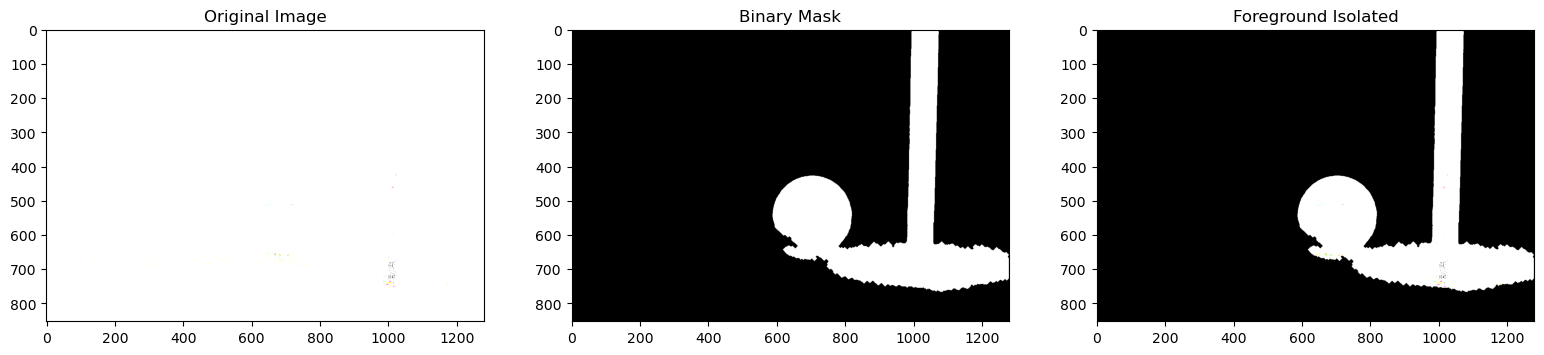

In [5]:
## For all requirements: The quality of the results is evaluated.


# 1- Read the image 

# [VERY IMPORTANT] and convert it to float: image = image.astype(float)

# read image golf
golf= imageio.imread('./imgs/exp1/golf.jpeg')
show_images([golf], ['Original Image'])
golf = golf.astype(float)
golfRed=golf[:,:,0]
golfGreen=golf[:,:,1]
golfBlue=golf[:,:,2]

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
axes[0].imshow(golf.astype(np.uint8))
axes[0].set_title("Original Image")
axes[1].imshow(golfRed, cmap='Reds')
axes[1].set_title("Red Channel")
axes[2].imshow(golfGreen, cmap='Greens')
axes[2].set_title("Green Channel")
axes[3].imshow(golfBlue, cmap='Blues')
axes[3].set_title("Blue Channel")
for ax in axes: ax.axis('off')
plt.show()

# 2- Retreive the 3 channels of the image(R,G,B) (will be used in the coming steps)


# 3- Visually (not by code) detect the dominating color channel (C) for the backgroung (R, G or B)

# 4- Draw the dominating channel (r, g or b) thresholded by some threshold (to make sure your choice is meaningful)


# 5- Get an intuitive way(There is a very simple way) to make a mask that can get the pixels where the values of the dominating channels 
# have larger values than the other channels with an appropriate threshold

# 6- display the binarized image


#first approach (iterative selection thresholding) 

# channel = golfGreen
# h, w = channel.shape
# corner_size = int(0.1 * min(h, w))
# #channel=gaussian_filter(channel, sigma=2)
# TL = channel[:corner_size, :corner_size]
# TR = channel[:corner_size, -corner_size:]
# BL = channel[-corner_size:, :corner_size]
# BR = channel[-corner_size:, -corner_size:]

# background_pixels = np.concatenate([TL.flatten(), TR.flatten(), BL.flatten(), BR.flatten()])
# Mb = np.mean(background_pixels)  

# foreground_pixels = channel[corner_size:-corner_size,corner_size:-corner_size].flatten()
# Mf = np.mean(foreground_pixels)

# T = (Mb + Mf) / 2

# stop_criteria = 1e-4
# while True:
#     bg_group = channel[channel > T]
#     fg_group = channel[channel <= T]

#     if len(bg_group) == 0 or len(fg_group) == 0:
#         break

#     Mb_new = np.mean(bg_group)
#     Mf_new = np.mean(fg_group)
#     T_new = (Mb_new + Mf_new) / 2

#     if abs(T - T_new) < stop_criteria:
#         break
#     T = T_new

# mask = (channel <= T)
# # mask = binary_opening(mask, iterations=10)
# #mask = binary_closing(mask, iterations=15)
# foreground = golf * mask[:, :, np.newaxis]
# show_images([golf, mask, foreground], ['Original Image', 'Binary Mask', 'Foreground Isolated'])
# showHist(channel)

threshold = 20

strong_Green = (golfGreen > golfRed + threshold) & (golfGreen > golfBlue + threshold)
mask = ~strong_Green
mask = binary_opening(mask, iterations=7)
mask = binary_closing(mask, iterations=3)
foreground = golf * mask[:, :, np.newaxis]
show_images([golf, mask, foreground], ['Original Image', 'Binary Mask', 'Foreground Isolated'])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

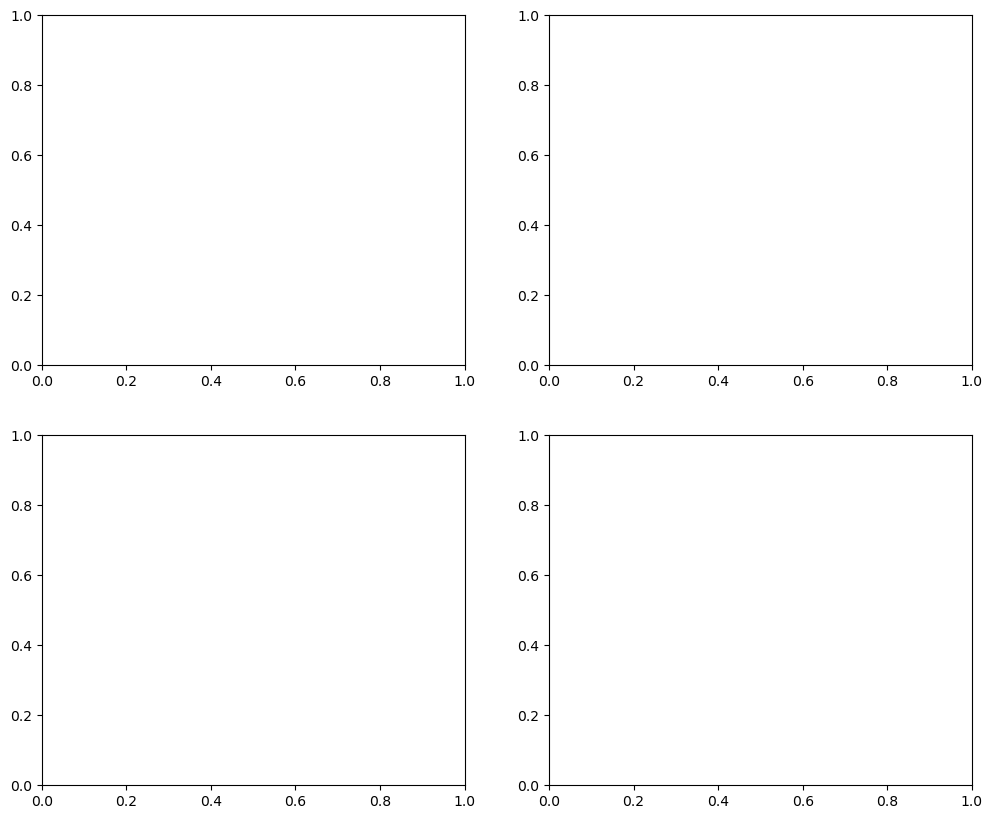

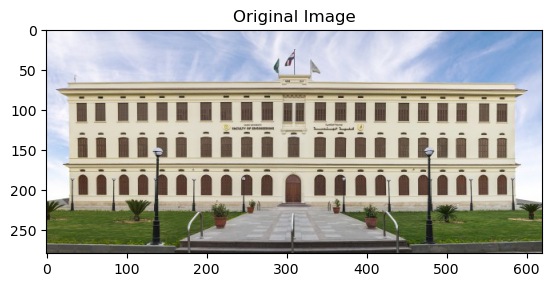

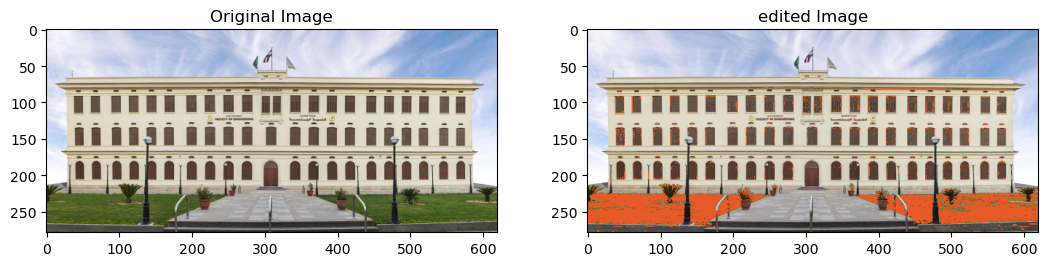

In [6]:
# 1- Get the required RGB color (Using a color picker)

CUFE=imageio.imread('./imgs/exp2/CUFE.png')
show_images([CUFE], ['Original Image'])
CUFE = CUFE.astype(float)
CUFERed=CUFE[:,:,0]
CUFEGreen=CUFE[:,:,1]
CUFEBlue=CUFE[:,:,2]  

grass_color = np.array([68, 93, 33], dtype=float)

distance = np.sqrt((CUFERed - grass_color[0])**2 +
                   (CUFEGreen - grass_color[1])**2 +
                   (CUFEBlue - grass_color[2])**2)


threshold = 37
mask = distance < threshold
target_color = np.array([230, 90, 40], dtype=float)  
CUFE_modified = CUFE.copy()
for c in range(3):
    CUFE_modified[:, :, c][mask] = target_color[c]


show_images([CUFE.astype(np.uint8), CUFE_modified.astype(np.uint8)], ['Original Image', 'edited Image'])

showHist(CUFEGreen.astype(np.uint8))



# 2- Read image

# 3- extract R, G and B channels (as float)

# 4- calculate differences FOR EACH CHANNEL (between the image and the required pixel value)

# 5- calculate overall distance from the given RGB color (use any appropriate distance measure, take care of the minus distances)

# 6-  create a mask by thresholding the differences

# 7- In the input image, Replace the pixels of the mask with the following color
# R = 230 , G = 90 , B=40

# 8- show the image or save it
